# Brouwer diagram

When dealing with oxides, it is very instructive to solve the charge neutrality conditions and compute equilibrium concentrations as a function of the oxygen partial pressure. This helps to interface with the experiment, where the most straighforward parameters to conctrol are $p_{O_2}$ and temperature.\
Changing $p_{O_2}$ means changing the chemical potential of oxygen:

$$ \mu_O(T,p_{O_2}) = \mu_O(T,p^0) + \frac{1}{2} k_B T \ln{\left( \frac{p_{O_2}}{p^0}\right)} $$
$$ \mu_O(T,p^{0}) = \mu_O(0\; K,p^{0}) + \Delta \mu_O(T,p^0) $$

where $\mu_O(0K,p^{0})$ is half the computed energy of the isolated $\mathrm{O_2}$ molecule at 0 K, and $\Delta \mu_O(T,p^0)$ is the variation in chemical potential with temperature at standard pressure. The latter can be determined using thermochemical tables (more details found [here](https://tuprints.ulb.tu-darmstadt.de/24481/).

In practise, for each $p_{O_2}$ value we have a different sets of chemical potentials. For each set of chemical potentials we solve the charge neutrality equation and determine equilibrium concentrations. `defermi` wraps this workflow in the `plot_brouwer_diagram` function of the `DefectsAnalysis` class. Let's put it into practise with our usual example:

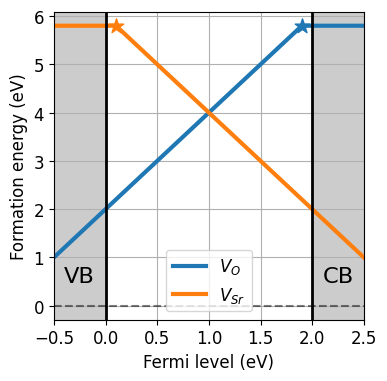

In [54]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)

chempots = {'O':-5,'Sr':-2}
da.plot_formation_energies(chempots,figsize=(4,4));

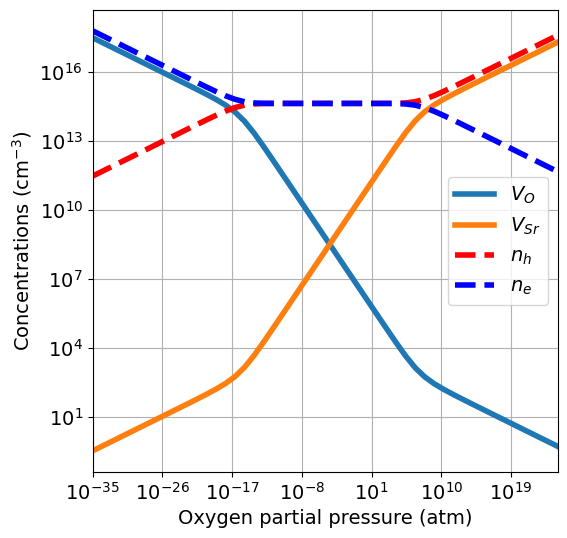

In [55]:
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        precursors={'SrO':-10},
                        oxygen_ref=-4.95, 
                        pressure_range=(1e-35,1e25),
                        figsize=(6,6),
                        fontsize=14);

Plots are produced with the `plotter.plot_pO2_vs_concentrations`function. Arguments can be passed as `**kwargs` in the `plot_brouwer_diagram` function, like `figsize` and `fontsize` in this example. 
The `bulk_dos` argument follows the same requirements as shown for the [Charge neutrality](./charge_neutrality.ipynb) tutorial. We explore now the several options and what happens under the hood.

### Chemical potentials 

There are mainly two ways we can define the chemical potentials starting from $\mu_O$:
- **Precursors**: Define a set of compounds that our target material is in contact with
- **Phase diagram**: Compute the phase diagram relative to the elements in our target material, and choose a specific region.

#### Precursors

We set the reservoir based on the compunds that are in contact with our material, usually at the synthesis stage.

Starting from the chemical potential of oxygen, the other chemical potentials are determined by the constraints 
$ E_{\mathrm{pfu}} = \sum_s c_s \mu_s $, where $c_s$ are the stochiometric coefficients and $\mu_s$ the chemical potentials.
For oxides with maximum 2 components, the target material itself is enough to determine the chemical potential of the other species.
For target oxides with more that 2 components, at least 2 compositions are needed to determine all chemical potentials.\

We now add Ti vacancies and Fe substitutions to our dataset, with our reference pristine material now being $\mathrm{SrTiO_3}$.

In [56]:
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': -4,'multiplicity': 1,'energy_diff': 20,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': 0,'multiplicity': 1,'energy_diff': 19.7,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Vac_O,{'O': -1},0,1,{},10.8
1,Vac_O,{'O': -1},2,1,{},7.0
2,Vac_Sr,{'Sr': -1},-2,1,{},8.0
3,Vac_Sr,{'Sr': -1},0,1,{},7.8
4,Vac_Ti,{'Ti': -1},-4,1,{},20.0
5,Vac_Ti,{'Ti': -1},0,1,{},19.7


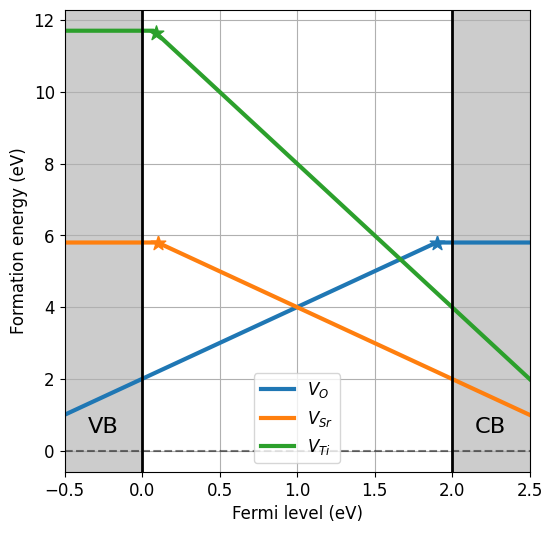

In [57]:
chempots = {'O':-5,'Sr':-2,'Ti':-8}
da.plot_formation_energies(chempots,figsize=(6,6));

Since now we have a 3-component material, we need at least 2 precursors to define the chemical potentials. We use the oxides $\mathrm{SrO}$ and $\mathrm{TiO_2}$ given by the equations:

\begin{cases}
E_{\mathrm{pfu}}(\mathrm{SrO}) = \mu_{\mathrm{Sr}} + \mu_{\mathrm{O}} \\
E_{\mathrm{pfu}}(\mathrm{TiO_2}) = \mu_{\mathrm{Ti}} + 2\mu_{\mathrm{O}}
\end{cases}

Fixing $\mu_O$ univocally determines $\mu_{\mathrm{Sr}}$ and $\mu_{\mathrm{Ti}}$.

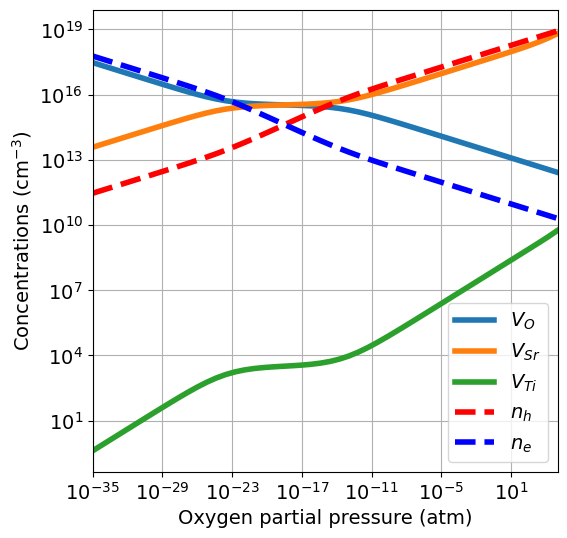

In [58]:
pressure_range = (1e-35,1e05)
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        precursors={'SrO':-12.79, 'TiO2':-28.3},
                        oxygen_ref=-4.95, 
                        pressure_range=pressure_range,
                        figsize=(6,6),
                        fontsize=14);

If the energies of the precursors are not available, they can be retrieved from the [Materials Project Database](https://next-gen.materialsproject.org/). The default DFT calculation types (`thermo_type`) is `GGA_GGA+U`. Instead of providing a dictionary, we give a list of compositions, and the energy p.f.u. of the most stable entry with that composition will be pulled from the database.

Pulling precursors energies from Materials Project database


Retrieving ThermoDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ThermoDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

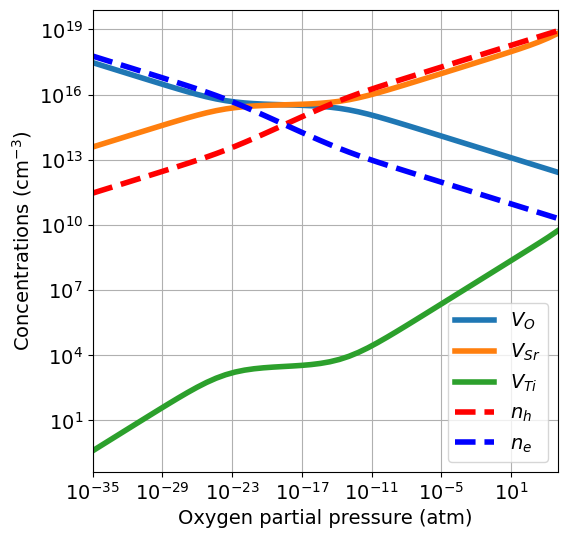

In [59]:
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        precursors=['SrO','TiO2'],
                        oxygen_ref=-4.95, 
                        pressure_range=pressure_range,
                        figsize=(6,6),
                        fontsize=14);

The set of chemical potentials used to compute the Brouwer diagram are computed from the precursors with the `chempots.oxygen.get_pressure_reservoirs_from_precursors` function. The chemical potentials values are stored in the `chempots`.

In [60]:
#da.chempots

In [61]:
from defermi.chempots.oxygen import get_pressure_reservoirs_from_precursors

res = get_pressure_reservoirs_from_precursors(
                                    precursors={'SrO':-12.79, 'TiO2':-28.3},
                                    oxygen_ref=-4.95,
                                    temperature=1000,
                                    pressure_range=(1e-35,1e08),
                                    npoints=10)
res

,O,Sr,Ti
1.000000e-35,-9.505102,-3.284898,-9.289796
5.995000e-31,-9.031095,-3.758905,-10.237809
3.594000e-26,-8.557089,-4.232911,-11.185823
2.154000e-21,-8.083082,-4.706918,-12.133836
1.292000e-16,-7.609075,-5.180925,-13.081850
7.743000e-12,-7.135068,-5.654932,-14.029863
4.642000e-07,-6.661062,-6.128938,-14.977877
2.783000e-02,-6.187055,-6.602945,-15.925890
1.668000e+03,-5.713048,-7.076952,-16.873903
1.000000e+08,-5.239042,-7.550958,-17.821917


Alternatively to passing the `precursors` argument, we can pass explicitely the sets of chemical potentials with the `reservoirs` argument. The format is a dictionary with partial pressures as keys and chemical potential dictionaries as values. In this way we can pass any set of chemical potentials and are not limited by a specific workflow. In the following example, we'll learn how to generate this dictionary using the $\mathrm{Sr-Ti-O}$ phase diagram.

### Phase diagram

Computing phase diagrams requires the calculations of hundreds of competing phases. Therefore, it can be useful at first to pull the data from the MP database. Morever, pymatgen provides a stable workflow for the analysis of phase diagrams in the `PhaseDiagram` class. We will pull the `PhaseDiagram` object from the database (like shown for chemical potentials in the [Formation energies](./formation_energies.ipynb) tutorial).

In [62]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

from pymatgen.analysis.chempot_diagram import ChemicalPotentialDiagram
from defermi.tools.materials_project import MPDatabase
from defermi.chempots.phase_diagram import PDHandler

phase_diagram = MPDatabase().get_phase_diagram_from_chemsys('Sr-Ti-O')
ChemicalPotentialDiagram(phase_diagram.entries).get_plot()

We obtain a range of stability for $\mathrm{SrTiO_3}$ with respect to competing phases. If now we fix $\mu_O$, since $ E(\mathrm{SrTiO_3}) = \mu_{Sr} + \mu_{Ti} + \mu_O $, we have only one degree of freedom left for the values of $\mu_{Ti}$ and $\mu_{Sr}$. The `get_pressure_reservoirs_from_phase_diagram` selects the avarage between the two stability borders of our target phase. In this example, one boundariy of stability is were $\mathrm{SrTiO_3}$ is in contact with $\mathrm{TiO_2}$ and the other were $\mathrm{SrTiO_3}$ is in contact with $\mathrm{Sr_3Ti_2O_7}$.

In [63]:
from defermi.chempots.oxygen import get_pressure_reservoirs_from_phase_diagram

res = get_pressure_reservoirs_from_phase_diagram(
                                            phase_diagram=phase_diagram,
                                            target_composition='SrTiO3',
                                            temperature=1000,
                                            pressure_range=pressure_range,
                                            npoints=10)
res

,Sr,Ti,O
1.000000e-35,-3.932459,-9.748467,-9.503063
2.783000e-31,-4.401820,-10.601915,-9.062127
7.743000e-27,-4.842757,-11.483788,-8.621190
2.154000e-22,-5.283693,-12.365661,-8.180254
5.995000e-18,-5.724630,-13.247534,-7.739317
1.668000e-13,-6.165566,-14.129407,-7.298381
4.642000e-09,-6.606503,-15.011279,-6.857444
1.292000e-04,-7.047439,-15.893152,-6.416508
3.594000e+00,-7.488376,-16.775025,-5.975571
1.000000e+05,-7.929312,-17.656898,-5.534635


The output is a `Reservoirs` object, which behaves like nested dictionaries (`{key:{element:chempot}}`). When created with this function, also stores the `PhaseDiagram` object and can be saved as `json` file with the `to_json` method. 

In [64]:
#res.to_json('res_SrTiO3.json')

print(res.pd)
res.mu_refs # elemental chemical potentials

Sr-Ti-O phase diagram
17 stable phases: 
TiO, Ti3O5, Sr, Ti2O, O2, SrO, Ti3O, SrO2, SrTi11O20, Sr3Ti2O7, Ti2O3, SrTiO3, Sr2Ti6O13, Sr2TiO4, Ti6O, TiO2, Ti


{'Sr': -1.6894934533333332, 'Ti': -7.895492016666666, 'O': -4.947961005}

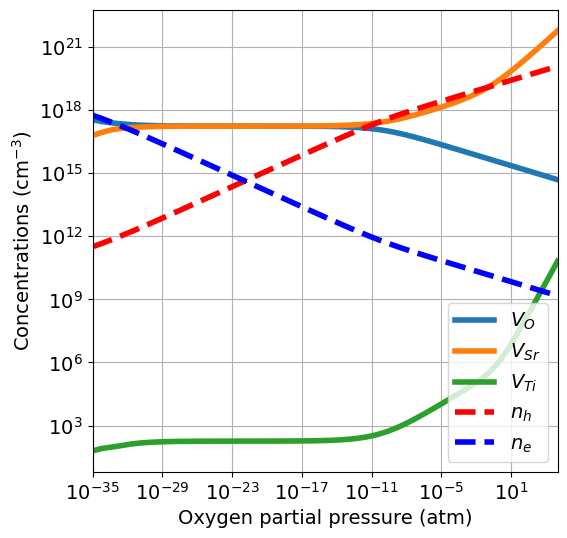

In [65]:
# increase the number of chemical potential dictionaries setting npoints
res = get_pressure_reservoirs_from_phase_diagram(
                                            phase_diagram=phase_diagram,
                                            target_composition='SrTiO3',
                                            temperature=1000,
                                            pressure_range=pressure_range,
                                            npoints=50) 
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        reservoirs=res, 
                        pressure_range=pressure_range,
                        figsize=(6,6),
                        fontsize=14);

Using this approach yields a similar but not identical result compared to using **precursors**. In fact, it yields smaller $\mu_{\mathrm{Sr}}$ values, which in turn make $V_{Sr}$ cheaper and extend the stochiometric region of the diagram (where $[V_O] = [V_{Sr}]$).

This demonstrates the importance of the choice of chemical potentials when computing the Brouwer diagram. Moreover, it is not always uniquely defined but can be partially arbitrary (especially for multi-component systems), which adds an extra layer of difficulty. However, it also demonstrates that the much simpler (and less computationally expensive) **precursors** approach already gives a valuable estimate of the defect chemistry behaviour. 

### Quenched conditions

Oxides are often synthesized at high temperatures. At this stage, a high T defect distribution is installed. When cooled down, often the mobility of ionic defects is too low for them to reach thermodynamic equilibrium. On the other hand, electrons are mobile and can reach equilibrium, meaning the charge states of these defects can change. Therefore, it can be very instructive to compute defect properties in quenched conditions, with the following workflow:
1) Solve charge neutrality at high T and compute defect concentrations
2) Fix the concentrations at low T to the high T values, solve charge neutrality with equilibrated charges

Equilibrated charges in quenched conditions can be computed following the fixed concentrations approach, explained in detail in the [Defect concentrations](./defect_concentrations.ipynb) tutorial. Brouwer diagrams in quenched conditions can be computed directly using the `plot_brouwer_diagram` function, and setting the `quench_temperature` argument:

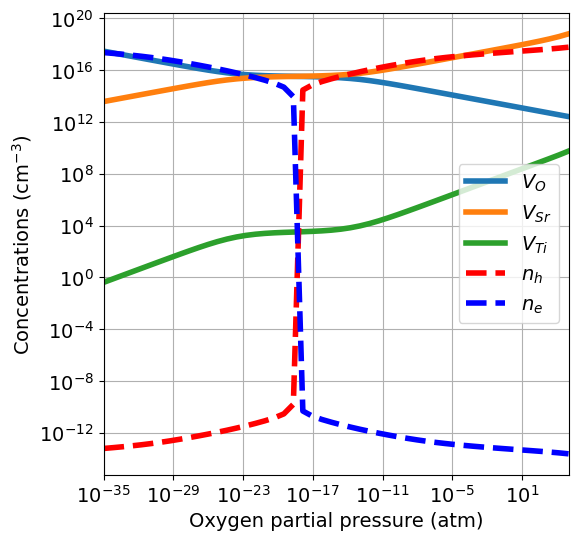

In [66]:
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        quench_temperature=300,
                        precursors={'SrO':-12.79, 'TiO2':-28.3},
                        oxygen_ref=-4.95, 
                        pressure_range=pressure_range,
                        figsize=(6,6),
                        fontsize=14);

In quenched conditions, at low temperature, the ionic defect concentrations are large and not enough electronic carriers are generated. Therefore the balance between electrons and holes is rapidly shifted when the equilibrium between ionic defects changes. It is also possible to quench only a subset of defects, while letting the others equilibrate. For this, we must set the `quenched_species` argument. In this case, we assume $V_O$ to be mobile and $V_{Sr}$ and $V_{Ti}$ to have low mobility, therefore we only equilibrate oxygen vacancies.

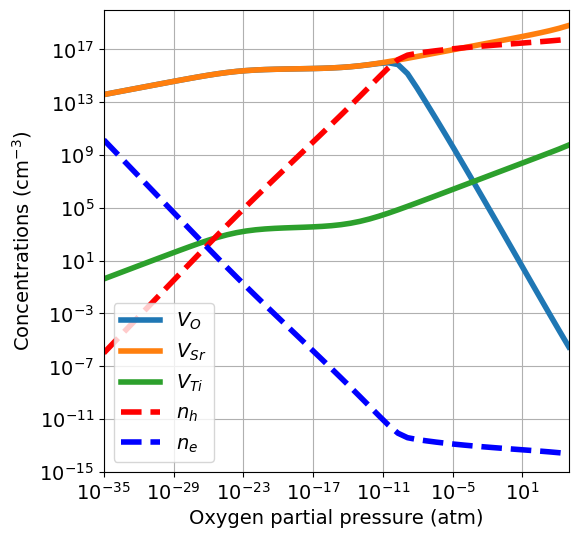

In [67]:
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                        temperature=1000,
                        quench_temperature=300,
                        quenched_species=['Vac_Sr','Vac_Ti'],
                        precursors={'SrO':-12.79, 'TiO2':-28.3},
                        oxygen_ref=-4.95, 
                        pressure_range=pressure_range,
                        figsize=(6,6),
                        fontsize=14,
                        ylim=(1e-15,1e20));

Since $V_O$ are equilibrated at low temperature, the concentrations are now smaller, and the $n$-type region dominated by oxygen vacancies disappears.

### Fixed concentrations

The same methodology can be applied if we have extrinsic defects, whose concentrations are fixed at the synthesis stage. We introduce $\mathrm{Fe}$ on $\mathrm{Sr}$ and $\mathrm{Ti}$ sites.

In [68]:
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': -4,'multiplicity': 1,'energy_diff': 20,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': 0,'multiplicity': 1,'energy_diff': 19.7,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge': -1,'multiplicity': 1,'energy_diff': 1.9,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge':0,'multiplicity':1,'energy_diff': 1.5, 'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 7.0,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 2,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",-1,1,{},1.9
1,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",0,1,{},1.5
2,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",1,1,{},7.0
3,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",2,1,{},6.5
4,Vac_O,{'O': -1},0,1,{},10.8
5,Vac_O,{'O': -1},2,1,{},7.0
6,Vac_Sr,{'Sr': -1},-2,1,{},8.0
7,Vac_Sr,{'Sr': -1},0,1,{},7.8
8,Vac_Ti,{'Ti': -1},-4,1,{},20.0
9,Vac_Ti,{'Ti': -1},0,1,{},19.7


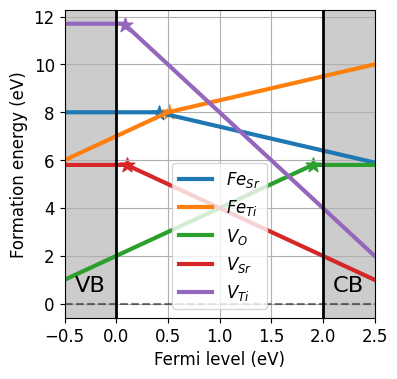

In [69]:
chempots = {'O':-5,'Sr':-2,'Fe':-8.5,'Ti':-8}
da.plot_formation_energies(chempots,figsize=(4,4));

Since the $\mathrm{Fe}$ concentration is fixed at the synthesis stage, we compute the Brouwer diagram fixing the concentration of iron, but the relative concentrations of $\mathrm{Fe}$ on different sites and charge states are still equilibrated.

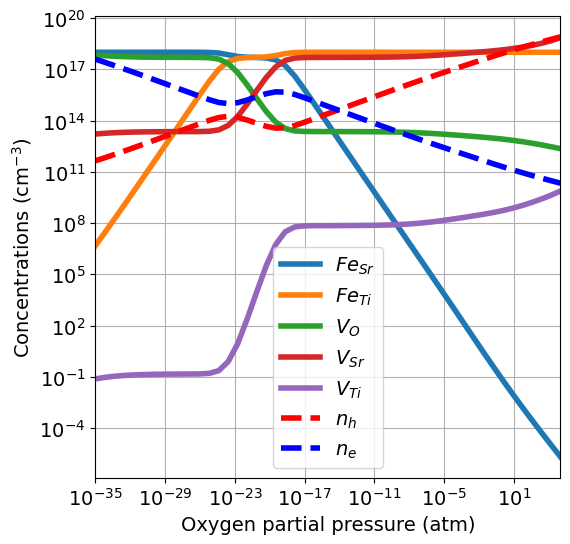

In [70]:
da.plot_brouwer_diagram(
                        bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},     # m0
                        temperature=1000,                           # K
                        fixed_concentrations={'Fe':1e18},           # cm^-3
                        precursors={'SrO':-12.79, 'TiO2':-28.3},    # eV
                        oxygen_ref=-4.95,                           # eV
                        pressure_range=pressure_range,              # atm
                        figsize=(6,6),
                        fontsize=14);

While the total concentration of iron is fixed, its effect on the defect equilibrium changes with the partial pressure. For low partial pressures $\mathrm{Fe_{Sr}}$ (acceptor) is dominant, and is compensated by $\mathrm{V_O}$. Increasing $p_{O_2}$ shifts the balence towards $\mathrm{Fe_{Ti}}$ (donor), which is compensated by $\mathrm{V_{Sr}}$. 